# Testing Masteller (2025) equation to La Jara data 

In [12]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

### Model Functions

τ*c evolution

In [13]:
def evolve_tau_c_gap_reset(
    tau_star,           # array of Shields stress τ*(t); np.nan where τ* is missing
    event_indices,      # integer indices where τ*c observations are available
    tau_c_obs,          # observed τ*c values at event_indices
    dt,                 # timestep between τ* samples (15 minutes in my case)
    k1, k2, epsilon,    # model parameters 
    gamma=2.5,          # fixed exponent from literature 
    tau_c_min=0.0343,   # minimum τ*c
    tau_c_max=0.3435    # maximum τ*c
):
    # initialize modeled τ*c array
    tau_c = np.full_like(tau_star, np.nan, dtype=float) # nan means τ*c is undefined (e.g., during gaps)
    tau_c_obs_dict = dict(zip(event_indices, tau_c_obs)) # dictionary of observed τ*c values
    was_in_gap = True # flag to track if we are in a gap or if we are starting from the beginning
    #tau_star = tau_star.values # ensure tau_star is a numpy array
    has_tau = ~np.isnan(tau_star) # boolean array indicating where τ* is available

    i = 0
    while i < len(tau_star):

        # case 1: τ* missing → mark gap and leave τ*c undefined
        if not has_tau[i]: 
            tau_c[i] = np.nan
            was_in_gap = True   # remember that we are in a gap
            # print("τ* missing at index", i, "; τ*c set to NaN")
            i += 1         
            continue

        # case 2: τ* resumes after gap → reinitialize τ*c if available τ*c if an observation exists
        if was_in_gap and i in tau_c_obs_dict:
            # τ* is resumed AND we have an observed τ*c
            tau_c_current = tau_c_obs_dict[i]
            tau_c[i] = tau_c_current
            was_in_gap = False   # reset the flag after initializing
            # print("reinitializing τ*c to observed value", tau_c_current, "at index", i)
            i += 1
            continue

        # case 3: normal forward evolution
        if i > 0 and not np.isnan(tau_c[i - 1]):
            tau_c_current = tau_c[i - 1] # previous τ*c

        else:
            # τ* present but τ*c not yet initialized
            # print("τ* present at index", i, "; τ*c undefined at index and cannot evolve")
            i += 1
            continue

        t = tau_star[i] # current τ*
        tc = np.clip(tau_c_current, tau_c_min, tau_c_max) # enforce bounds on τ*c
        
        # calculate feedback parameter B
        B = (tau_c_max - tc) / (tau_c_max - tau_c_min)
        # transport capacity
        R = t / tc
        # strengthening term
        strengthen = k1 * B / (1.0 + R**(-gamma))
        # weakening term
        if R > 1:
            weaken = k2 * (1 - B) * (R - 1)**epsilon
        else:
            weaken = 0.0

        # forward euler update
        d_tau_c = (strengthen - weaken) * dt
        # print(f"at τ*: {t:.3f}, evolving τ*c from {tau_c_current:.3f}, at index {i}, to {tc + d_tau_c:.3f}, transport capacity: {R:.3f}, strengthen: {strengthen:.5f}, weaken: {weaken:.10f}")
        tau_c[i] = tc + d_tau_c
        i += 1

    return tau_c


In [14]:
def evolve_tau_c_gap_hold(
    tau_star,           # array of Shields stress τ*(t); np.nan where τ* is missing
    event_indices,      # integer indices where τ*c observations are available
    tau_c_obs,          # observed τ*c values at event_indices
    dt,
    k1, k2, epsilon,
    gamma=2.5,
    tau_c_min=0.0343,
    tau_c_max=0.3435
):
    """
    hold τ*c constant during τ* gaps; resume evolution when τ* returns
    only initialize τ*c if an observation exists and no prior τ*c is available
    """
    tau_c = np.full_like(tau_star, np.nan, dtype=float)
    tau_c_obs_dict = dict(zip(event_indices, tau_c_obs))

    tau_c_current = None
    initialized = False

    for i in range(len(tau_star)):
        t = tau_star[i]

        # initialize when first observation exists
        if not initialized and i in tau_c_obs_dict:
            tau_c_current = tau_c_obs_dict[i]
            tau_c[i] = tau_c_current
            initialized = True
            continue

        # gap: hold τ*c constant if available
        if np.isnan(t): # τ* missing
            if tau_c_current is not None: # hold previous τ*c
                tau_c[i] = tau_c_current
            continue

        # if still uninitialized, cannot evolve
        if tau_c_current is None:
            continue

        tc = np.clip(tau_c_current, tau_c_min, tau_c_max)
        B = (tau_c_max - tc) / (tau_c_max - tau_c_min)
        R = t / tc

        strengthen = k1 * B / (1.0 + R**(-gamma))
        weaken = k2 * (1 - B) * (R - 1)**epsilon if R > 1 else 0.0

        d_tau_c = (strengthen - weaken) * dt
        tau_c_current = tc + d_tau_c
        tau_c[i] = tau_c_current

    return tau_c

In [15]:
def evolve_tau_c_gap_minimum(
    tau_star,           # array of Shields stress τ*(t); np.nan where τ* is missing
    event_indices,      # integer indices where τ*c observations are available
    tau_c_obs,          # observed τ*c values at event_indices
    dt,
    k1, k2, epsilon,
    gamma=2.5,
    tau_c_min=0.0343,
    tau_c_max=0.3435
):
    """
    τ*c goes to τ*cmin during τ* gaps; resume evolution when τ* returns
    """
    tau_c = np.full_like(tau_star, np.nan, dtype=float)
    tau_c_obs_dict = dict(zip(event_indices, tau_c_obs))

    tau_c_current = None
    initialized = False

    for i in range(len(tau_star)):
        t = tau_star[i]

        # initialize when first observation exists
        if not initialized and i in tau_c_obs_dict:
            tau_c_current = tau_c_obs_dict[i]
            tau_c[i] = tau_c_current
            initialized = True
            continue

        # gap: reset τ*c to minimum if τ* missing
        if np.isnan(t):  # τ* missing
            if tau_c_current is not None:  # set to minimum if in gap but had previous τ*c
                tau_c_current = tau_c_min
                tau_c[i] = tau_c_min                
            continue

        # if still uninitialized, cannot evolve
        if tau_c_current is None:
            continue

        tc = np.clip(tau_c_current, tau_c_min, tau_c_max)
        B = (tau_c_max - tc) / (tau_c_max - tau_c_min)
        R = t / tc

        strengthen = k1 * B / (1.0 + R**(-gamma))
        weaken = k2 * (1 - B) * (R - 1)**epsilon if R > 1 else 0.0

        d_tau_c = (strengthen - weaken) * dt
        tau_c_current = tc + d_tau_c
        tau_c[i] = tau_c_current

    return tau_c

Parameter calibration [(grid search)](https://en.wikipedia.org/wiki/Hyperparameter_optimization)


In [16]:
def calibrate_parameters(
    tau_star,
    event_indices,      # indices of event start times
    tau_c_obs,          # observed τ*c at events
    dt,
    k1_vals,
    k2_vals,
    eps_vals,
    gamma = 2.5,
    tau_c_min = 0.0343,
    tau_c_max = 0.3435,
    constant_tc = False,
    minimum_reset = False
):
    """
    grid-search calibration of the model using mean absolute error (MAE) 
    """
    results = []
    for k1_idx, k1 in enumerate(k1_vals):
        print(f"Testing k1 = {k1:.6e} ({k1_idx + 1}/{len(k1_vals)})")
        for k2 in k2_vals:
            for eps in eps_vals:
                if constant_tc == True:
                    tau_c_model = evolve_tau_c_gap_hold(tau_star, event_indices, tau_c_obs, dt, k1, k2, eps, gamma, tau_c_min, tau_c_max)
                else:
                    if minimum_reset == True:
                        tau_c_model = evolve_tau_c_gap_minimum(tau_star, event_indices, tau_c_obs, dt, k1, k2, eps, gamma, tau_c_min, tau_c_max)
                    else:
                        tau_c_model = evolve_tau_c_gap_reset(tau_star, event_indices, tau_c_obs, dt, k1, k2, eps, gamma, tau_c_min, tau_c_max)
                # extract modeled τ*c at event starts
                tau_c_pred = tau_c_model[event_indices]
                # calculate mean absolute error (paper uses MAE), and ignore NaNs
                mae = np.nanmean(np.abs(tau_c_pred - tau_c_obs))
                results.append({
                    "k1": k1,
                    "k2": k2,
                    "epsilon": eps,
                    "MAE": mae
                })
    return results


Parameter ranges 

In [17]:
# start, stop, number of values
k1_vals = np.logspace(-6, -4, 40) # values evenly spaced on log scale
k2_vals = np.logspace(-5, -3, 40)
eps_vals = np.linspace(0, 2, 20) # values from 0 to 2
print("eps_vals:", eps_vals)

eps_vals: [0.         0.10526316 0.21052632 0.31578947 0.42105263 0.52631579
 0.63157895 0.73684211 0.84210526 0.94736842 1.05263158 1.15789474
 1.26315789 1.36842105 1.47368421 1.57894737 1.68421053 1.78947368
 1.89473684 2.        ]


Import and format data

In [18]:
# import data 
tau_star_2022 = pd.read_csv('../../total_shear_stress_2022.csv')
tau_star_2023 = pd.read_csv('../../total_shear_stress_2023.csv')
tauc_events = pd.read_csv('tauc_events_exceedance.csv', parse_dates=['datetime'], index_col='datetime')

# convert to datetime and set as index
tau_star_2022['time'] = pd.to_datetime(tau_star_2022['time']) 
tau_star_2023['time'] = pd.to_datetime(tau_star_2023['time'])
tau_star_2022 = tau_star_2022.set_index('time')
tau_star_2023 = tau_star_2023.set_index('time')

# create continuous 15-minute time index from first timestamp to last
continuous_index = pd.date_range(start=tau_star_2022.index.min(), end=tau_star_2023.index.max(), freq='15min')
# reindex both dataframes to continuous timeline
df_2022_continuous = tau_star_2022.reindex(continuous_index)
df_2023_continuous = tau_star_2023.reindex(continuous_index)

# combine: use 2022 where available, fill gaps with 2023
df_tau = df_2022_continuous.fillna(df_2023_continuous)
df_tau.index.name = 'time'
# change tau column name to 'tau'
df_tau = df_tau.rename(columns={'0': 'tau'})

print(f"Combined τ* dataframe shape: {df_tau.shape}")
print(f"Data gaps (NaNs): {df_tau.isna().sum().sum()}")

# delete everything before 2022-07-14 (we don't care about earlier times)
df_tau = df_tau[df_tau.index >= '2022-08-03 15:00']

Combined τ* dataframe shape: (54336, 1)
Data gaps (NaNs): 22490


In [19]:
# convert tau to dimenstionless Shields stress τ*
rho_s = 2650.0  # sediment density, kg/m3
rho = 1000.0   # fluid density, kg/m3
g = 9.81       # gravitational acceleration, m/s2
d50 = 0.04364    # median grain diameter, m

df_tau['tau_star'] = df_tau['tau'] / ((rho_s - rho) * g * d50)

In [27]:
# build integer index mapping
time_to_index = pd.Series(
    np.arange(len(df_tau)), 
    index=df_tau.index
)
event_indices = time_to_index.loc[tauc_events.index].to_numpy() # integer indices of event times
tau_c_obs = tauc_events["tauc"].to_numpy() # observed τ*c values
tau_star = df_tau["tau_star"].to_numpy() # τ* time series array

## 1) Calibration assuming τ*c re-initializes

In [10]:
results = calibrate_parameters(
    tau_star,
    event_indices,
    tau_c_obs,
    dt=15,               
    k1_vals=k1_vals,
    k2_vals=k2_vals,
    eps_vals=eps_vals,
    gamma=2.5,
    tau_c_min=0.08,
    tau_c_max=0.2
)

best = min(results, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing k1 = 1.000000e-06 (1/40)


KeyboardInterrupt: 

In [10]:
test = evolve_tau_c_gap_reset(
    tau_star,           # array of Shields stress τ*(t); np.nan where τ* is missing
    event_indices,      # integer indices where τ*c observations are available
    tau_c_obs,          # observed τ*c values at event_indices
    dt=15,                 # timestep between τ* samples (15 minutes in my case)
    k1=1e-06, k2=0.00030702906297578496, epsilon=1.789473684210526,    # best fit model parameters from above
    gamma=2.5,          # fixed exponent from literature 
    tau_c_min=0.08,   # minimum τ*c
    tau_c_max=0.2    # maximum τ*c
    )

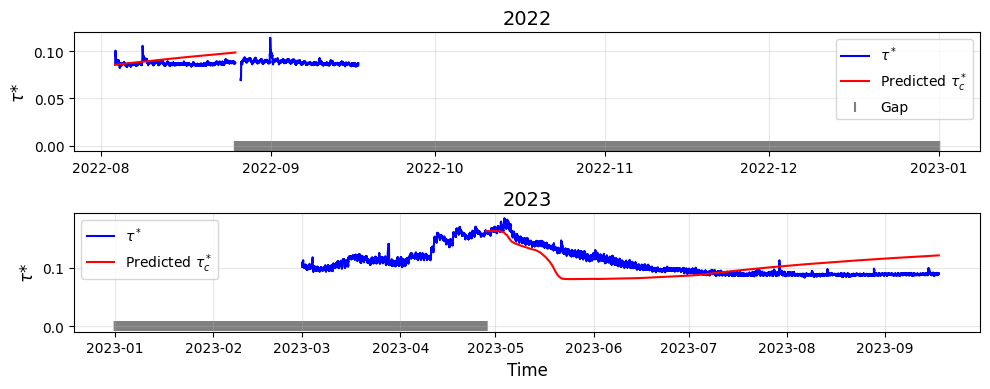

In [11]:
# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(test, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

# select years
years = [2022, 2023]

fig, axes = plt.subplots(nrows=len(years), ncols=1, figsize=(10, 4), sharex=False)

for ax, year in zip(axes, years):
    # select data for the year
    mask = time_to_index.index.year == year
    tau_year = tau_star_series[mask]
    tauc_year = tau_c_pred_series[mask]
    
    ax.plot(tau_year.index, tau_year.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
    ax.plot(tauc_year.index, tauc_year.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
    
    # optional: highlight NaNs in tau_c_pred (data gaps)
    gap_mask = np.isnan(tauc_year.values)
    ax.scatter(tauc_year.index[gap_mask], np.zeros(sum(gap_mask)), color='gray', marker='|', s=50, label='Gap' if year==2022 else "")
    
    ax.set_ylabel(r'$\tau$*', fontsize=12)
    ax.set_title(f'{year}', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time', fontsize=12)

plt.tight_layout()
plt.show()

Define acceptance criterion

In [12]:
#results_df = pd.DataFrame(results) # this one if running calibration now
results_df = pd.read_csv('calibration/re_initialize_tauc/third_parameter_iteration.csv') # run this one to load existing results

# will assume all parameter combinations within 20% of the best fit are acceptable
mae_min = results_df["MAE"].min()
df_good = results_df[results_df["MAE"] <= 1.05 * mae_min]

In [13]:
# examine parameter distributions 
df_good[["k1", "k2", "epsilon"]].describe()

,k1,k2,epsilon
count,5.000000e+00,5.000000,5.000000
mean,1.078343e-06,0.000352,1.600000
std,1.182996e-07,0.000276,0.547723
min,1.000000e-06,0.000046,1.000000
25%,1.000000e-06,0.000052,1.000000
50%,1.000000e-06,0.000554,2.000000
75%,1.125336e-06,0.000554,2.000000
max,1.266380e-06,0.000554,2.000000


In [14]:
len(df_good) / len(results_df)

0.0003125

### Plots

2022 τ*c evolution

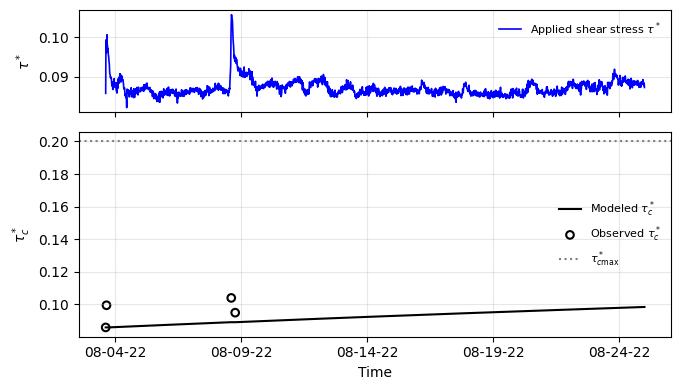

In [15]:
mask = (time_to_index.index.year == 2022) & (time_to_index.index < '2022-08-25')
tau_2022 = tau_star_series[mask]
tauc_2022 = tau_c_pred_series[mask]
obs_tauc_2022 = tauc_events.loc[(tauc_events.index.year == 2022) & (tauc_events.index < '2022-08-25'), "tauc"]
tau_c_max = 0.2

# create figure with two stacked panels
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 4), sharex=True, gridspec_kw={"height_ratios": [1, 2]})

# TOP PANEL: applied shear stress τ*
ax1.plot(tau_2022.index, tau_2022, color="blue", linewidth=1.2, label=r"Applied shear stress $\tau^*$")

ax1.set_ylabel(r"$\tau^*$")
ax1.legend(frameon=False, fontsize=8)
ax1.grid(True, alpha=0.3)

# BOTTOM PANEL: τ*c evolution
ax2.plot(tauc_2022.index, tauc_2022, color="black", linewidth=1.5, label=r"Modeled $\tau^*_c$")
ax2.scatter(obs_tauc_2022.index, obs_tauc_2022, facecolors="none", edgecolors="black", s=30, 
            linewidth=1.5, label=r"Observed $\tau^*_c$") # scatter observed τ*c values
ax2.axhline(tau_c_max, color="gray", linestyle=":", linewidth=1.5, label=r"$\tau^*_{c\max}$") # τ*c max reference line

ax2.set_ylabel(r"$\tau^*_c$")
ax2.set_xlabel("Time")
ax2.legend(frameon=False, fontsize=8)
ax2.xaxis.set_major_locator(mdates.DayLocator(interval=5))  # show every 3 days
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d-%y'))  # format as month-day
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

2023 τ*c evolution

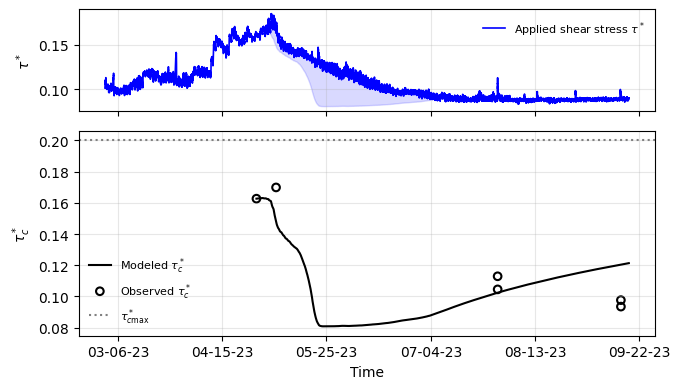

In [16]:
mask = (time_to_index.index.year == 2023) & (time_to_index.index < '2023-09-30')
tau_2023 = tau_star_series[mask]
tauc_2023 = tau_c_pred_series[mask]
obs_tauc_2023 = tauc_events.loc[(tauc_events.index.year == 2023) & (tauc_events.index < '2023-09-30'), "tauc"]
tau_c_max = 0.2

# create figure with two stacked panels
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 4), sharex=True, gridspec_kw={"height_ratios": [1, 2]})


# TOP PANEL: applied shear stress τ*
ax1.plot(tau_2023.index, tau_2023, color="blue", linewidth=1.2, label=r"Applied shear stress $\tau^*$")
ax1.fill_between(tau_2023.index, tau_2023, tauc_2023, where=(tau_2023 > tauc_2023), alpha=0.15, interpolate=True, color='blue')

ax1.set_ylabel(r"$\tau^*$")
ax1.legend(frameon=False, fontsize=8)
ax1.grid(True, alpha=0.3)

# BOTTOM PANEL: τ*c evolution
ax2.plot(tauc_2023.index, tauc_2023, color="black", linewidth=1.5, label=r"Modeled $\tau^*_c$")
ax2.scatter(obs_tauc_2023.index, obs_tauc_2023, facecolors="none", edgecolors="black", s=30, 
            linewidth=1.5, label=r"Observed $\tau^*_c$") # scatter observed τ*c values
ax2.axhline(tau_c_max, color="gray", linestyle=":", linewidth=1.5, label=r"$\tau^*_{c\max}$") # τ*c max reference line

ax2.set_ylabel(r"$\tau^*_c$")
ax2.set_xlabel("Time")
ax2.legend(frameon=False, fontsize=8)
ax2.xaxis.set_major_locator(mdates.DayLocator(interval=40))  # show every 3 days
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d-%y'))  # format as month-day
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Just the shear stress and the events

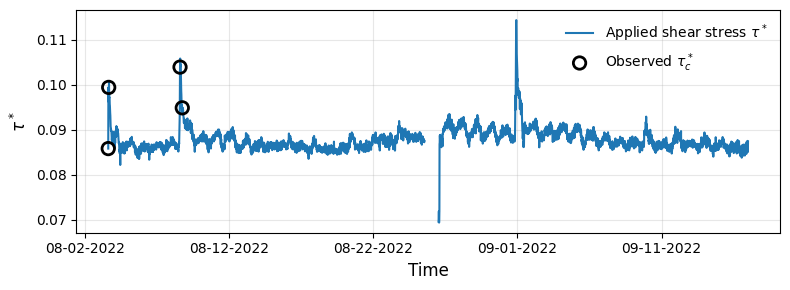

In [17]:
# 2022 plot
mask_2022 = (time_to_index.index.year == 2022) & (time_to_index.index < '2022-09-30')
tau_2022 = tau_star_series[mask_2022]
obs_tauc_2022 = tauc_events.loc[(tauc_events.index.year == 2022) & (tauc_events.index < '2022-09-30'), "tauc"]

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(tau_2022.index, tau_2022, linewidth=1.5, label=r"Applied shear stress $\tau^*$")
ax.scatter(obs_tauc_2022.index, obs_tauc_2022, facecolors="none", edgecolors="black", s=80, 
           linewidth=2, label=r"Observed $\tau^*_c$", zorder=5)

ax.set_ylabel(r"$\tau^*$", fontsize=12)
ax.set_xlabel("Time", fontsize=12)
ax.legend(frameon=False, fontsize=10)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d-%Y'))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



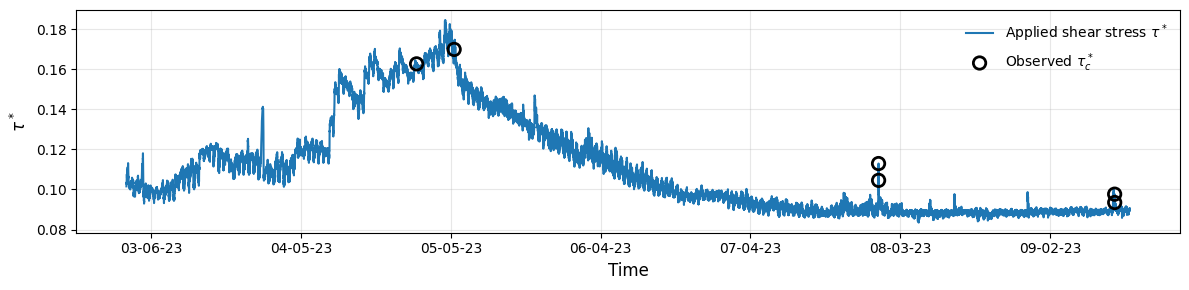

In [18]:
# 2023 plot
mask_2023 = (time_to_index.index.year == 2023) & (time_to_index.index < '2023-09-30')
tau_2023 = tau_star_series[mask_2023]
obs_tauc_2023 = tauc_events.loc[(tauc_events.index.year == 2023) & (tauc_events.index < '2023-09-30'), "tauc"]

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(tau_2023.index, tau_2023, linewidth=1.5, label=r"Applied shear stress $\tau^*$")
ax.scatter(obs_tauc_2023.index, obs_tauc_2023, facecolors="none", edgecolors="black", s=80, 
           linewidth=2, label=r"Observed $\tau^*_c$", zorder=5)

ax.set_ylabel(r"$\tau^*$", fontsize=12)
ax.set_xlabel("Time", fontsize=12)
ax.legend(frameon=False, fontsize=10)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=30))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d-%y'))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Storm 4

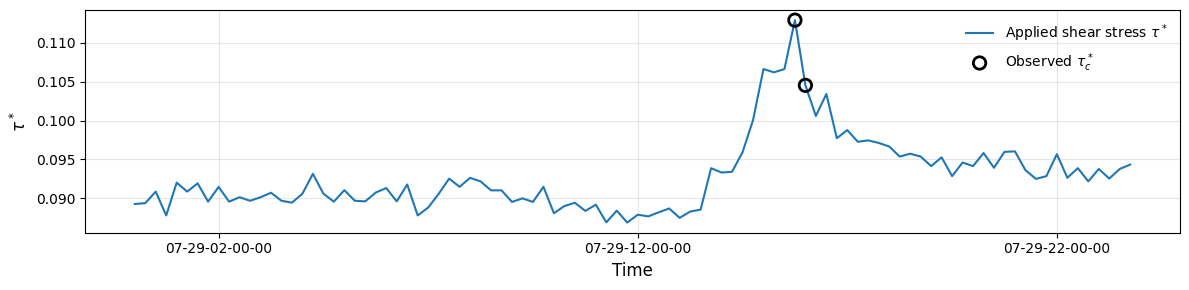

In [19]:
# 2023 summer plot (zoomed in)
mask_2023_summer = (time_to_index.index.year == 2023) & (time_to_index.index >= '2023-07-29') & (time_to_index.index < '2023-07-30')
tau_2023_summer = tau_star_series[mask_2023_summer]
obs_tauc_2023_summer = tauc_events.loc[(tauc_events.index.year == 2023) & (tauc_events.index >= '2023-07-29') & (tauc_events.index < '2023-07-30'), "tauc"]

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(tau_2023_summer.index, tau_2023_summer, linewidth=1.5, label=r"Applied shear stress $\tau^*$")
ax.scatter(obs_tauc_2023_summer.index, obs_tauc_2023_summer, facecolors="none", edgecolors="black", s=80, 
           linewidth=2, label=r"Observed $\tau^*_c$", zorder=5)

ax.set_ylabel(r"$\tau^*$", fontsize=12)
ax.set_xlabel("Time", fontsize=12)
ax.legend(frameon=False, fontsize=10)
ax.xaxis.set_major_locator(mdates.HourLocator(interval=10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d-%H-%M-%S'))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### MAE comparison to constant τ*c

In [20]:
# constant (mean) τ*c baseline
tau_c_mean = np.nanmean(tau_c_obs)
# "predicted" τ*c assuming constant mean
tau_c_const_pred = np.full_like(tau_c_obs, tau_c_mean)
# extract modeled τ*c at events
tau_c_model_pred = test[event_indices]

# Compute MAE
mae_model = np.nanmean(np.abs(tau_c_model_pred - tau_c_obs))
mae_const = np.nanmean(np.abs(tau_c_const_pred - tau_c_obs))

print(f"MAE (dynamic τ*c model): {mae_model:.4f}")
print(f"MAE (constant mean τ*c): {mae_const:.4f}")
print(f"Model improvement over constant τ*c (%): {(1 - mae_model / mae_const) * 100:.1f}")


MAE (dynamic τ*c model): 0.0118
MAE (constant mean τ*c): 0.0216
Model improvement over constant τ*c (%): 45.3


In [21]:
print(tau_c_mean)

0.1125


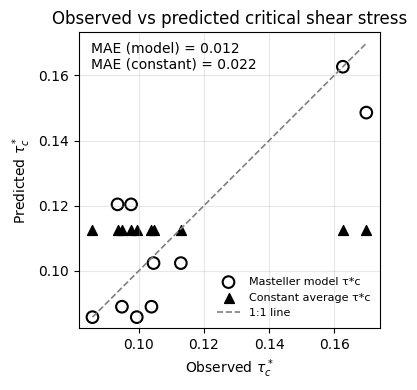

In [22]:
# axis limits for 1:1 line
vmin = min(tau_c_obs.min(), tau_c_model_pred.min())
vmax = max(tau_c_obs.max(), tau_c_model_pred.max())

plt.figure(figsize=(4, 4))

# masteller model
plt.scatter(tau_c_obs, tau_c_model_pred, facecolors="none", edgecolors="black", s=70, linewidth=1.5, label="Masteller model τ*c")
# constant τ*c
plt.scatter(tau_c_obs, tau_c_const_pred, color="black", s=50, marker="^", label="Constant average τ*c")
# 1:1 line
plt.plot([vmin, vmax], [vmin, vmax], linestyle="--", color="gray", linewidth=1.2, label="1:1 line")

plt.text(0.04, 0.97, f"MAE (model) = {mae_model:.3f}\nMAE (constant) = {mae_const:.3f}", transform=plt.gca().transAxes, verticalalignment="top")

plt.xlabel("Observed $\\tau^*_c$")
plt.ylabel("Predicted $\\tau^*_c$")
plt.title("Observed vs predicted critical shear stress")
plt.legend(frameon=False, fontsize=8)
plt.grid(alpha=0.3)
plt.axis("equal")

plt.tight_layout()
plt.show()


### Testing this calibration assuming constant τ*c during data gaps
during data gaps

In [24]:
test_hold = evolve_tau_c_gap_hold(
    tau_star,           # array of Shields stress τ*(t); np.nan where τ* is missing
    event_indices,      # integer indices where τ*c observations are available
    tau_c_obs,          # observed τ*c values at event_indices
    dt=15,                 # timestep between τ* samples (15 minutes in my case)
    k1=1e-06, k2=0.00030702906297578496, epsilon=1.789473684210526,    # these are from the third parameter iteration above
    gamma=2.5,          # fixed exponent from literature 
    tau_c_min=0.08,   # minimum τ*c
    tau_c_max=0.2    # maximum τ*c
    )

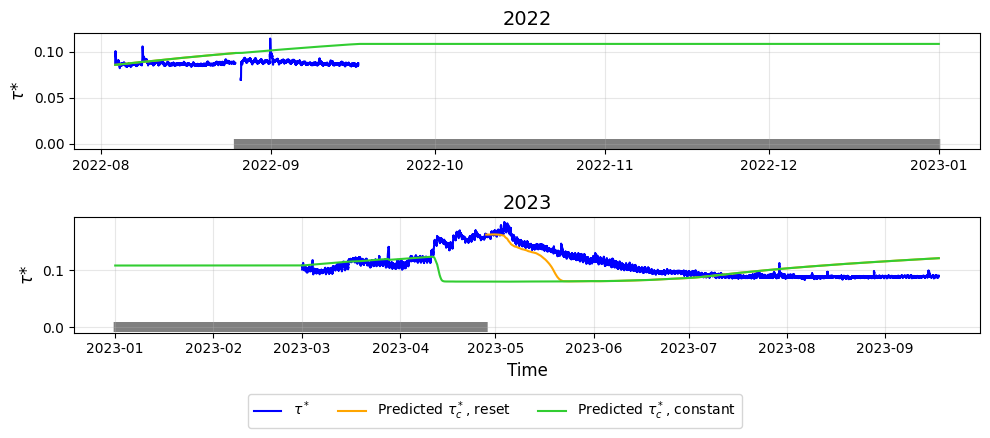

In [25]:
# tau_c_pred is the array returned by your function
tau_c_test_series = pd.Series(test, index=time_to_index.index)
tau_c_hold_series = pd.Series(test_hold, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

# select years
years = [2022, 2023]

fig, axes = plt.subplots(nrows=len(years), ncols=1, figsize=(10, 4), sharex=False)

for ax, year in zip(axes, years):
    # select data for the year
    mask = time_to_index.index.year == year
    tau_year = tau_star_series[mask]
    tauc_year = tau_c_test_series[mask]
    tauc_hold_year = tau_c_hold_series[mask]
    
    ax.plot(tau_year.index, tau_year.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
    ax.plot(tauc_year.index, tauc_year.values, color='orange', label=r'Predicted $\tau_c^*$, reset', linewidth=1.5)
    ax.plot(tauc_hold_year.index, tauc_hold_year.values, color='limegreen', label=r'Predicted $\tau_c^*$, constant', linewidth=1.5)
    
    # optional: highlight NaNs in tau_c_pred (data gaps)
    gap_mask = np.isnan(tauc_year.values)
    ax.scatter(tauc_year.index[gap_mask], np.zeros(sum(gap_mask)), color='gray', marker='|', s=50)
    
    ax.set_ylabel(r'$\tau$*', fontsize=12)
    ax.set_title(f'{year}', fontsize=14)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time', fontsize=12)

# Create single legend from first axis
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=3, fontsize=10)

plt.tight_layout(h_pad=1.5, w_pad=0.5)
plt.show()

In [26]:
# extract modeled τ*c at events
tau_c_model_test = test[event_indices]
tau_c_model_hold = test_hold[event_indices]

# Compute MAE
mae_model_test = np.nanmean(np.abs(tau_c_model_test - tau_c_obs))
mae_model_hold = np.nanmean(np.abs(tau_c_model_hold - tau_c_obs))

print(f"MAE (dynamic τ*c model, reset): {mae_model_test:.4f}")
print(f"MAE (dynamic τ*c model, continuous): {mae_model_hold:.4f}")   
print(f"Improvement of resetting τ*c over continuous assumption (%): {(1 - mae_model_test / mae_model_hold) * 100:.1f}")

MAE (dynamic τ*c model, reset): 0.0118
MAE (dynamic τ*c model, continuous): 0.0269
Improvement of resetting τ*c over continuous assumption (%): 56.1


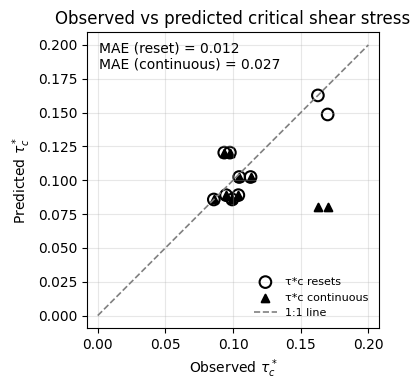

In [27]:
# axis limits for 1:1 line
vmin = 0#min(tau_c_model_test.min(), tau_c_model_hold.min())
vmax = 0.2#max(tau_c_model_test.max(), tau_c_model_hold.max())

plt.figure(figsize=(4, 4))

# with tau reset at gaps
plt.scatter(tau_c_obs, tau_c_model_test, facecolors="none", edgecolors="black", s=70, linewidth=1.5, label="τ*c resets")
# with tau held constant at gaps
plt.scatter(tau_c_obs, tau_c_model_hold, facecolors="black", s=30, linewidth=1.5, label="τ*c continuous", marker="^")
# 1:1 line
plt.plot([vmin, vmax], [vmin, vmax], linestyle="--", color="gray", linewidth=1.2, label="1:1 line")

plt.text(0.04, 0.97, f"MAE (reset) = {mae_model_test:.3f}\nMAE (continuous) = {mae_model_hold:.3f}", transform=plt.gca().transAxes, verticalalignment="top")

plt.xlabel("Observed $\\tau^*_c$")
plt.ylabel("Predicted $\\tau^*_c$")
plt.title("Observed vs predicted critical shear stress")
plt.legend(frameon=False, fontsize=8)
plt.grid(alpha=0.3)
plt.axis("equal")

plt.tight_layout()
plt.show()


## 2) Calibrating assuming continuous τ*c during data gaps

In [28]:
# start, stop, number of values
k1_vals = np.logspace(-6, -2, 40) # values evenly spaced on log scale
k2_vals = np.logspace(-6, -2, 40)
eps_vals = np.linspace(1, 10, 10) # values from 0 to 10
print("eps_vals:", eps_vals)

eps_vals: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]


In [ ]:
results = calibrate_parameters(
    tau_star,
    event_indices,
    tau_c_obs,
    dt=15,               
    k1_vals=k1_vals,
    k2_vals=k2_vals,
    eps_vals=eps_vals,
    gamma=2.5,
    tau_c_min=0.08,
    tau_c_max=0.2,
    constant_tc=True
)

best = min(results, key=lambda x: x["MAE"])

print("Best-fit parameters:")
print(best)


Testing k1 = 1.000000e-06 (1/40)
Testing k1 = 1.266380e-06 (2/40)
Testing k1 = 1.603719e-06 (3/40)
Testing k1 = 2.030918e-06 (4/40)
Testing k1 = 2.571914e-06 (5/40)
Testing k1 = 3.257021e-06 (6/40)
Testing k1 = 4.124626e-06 (7/40)
Testing k1 = 5.223345e-06 (8/40)
Testing k1 = 6.614741e-06 (9/40)
Testing k1 = 8.376776e-06 (10/40)
Testing k1 = 1.060818e-05 (11/40)
Testing k1 = 1.343399e-05 (12/40)
Testing k1 = 1.701254e-05 (13/40)
Testing k1 = 2.154435e-05 (14/40)
Testing k1 = 2.728333e-05 (15/40)
Testing k1 = 3.455107e-05 (16/40)
Testing k1 = 4.375479e-05 (17/40)
Testing k1 = 5.541020e-05 (18/40)
Testing k1 = 7.017038e-05 (19/40)
Testing k1 = 8.886238e-05 (20/40)
Testing k1 = 1.125336e-04 (21/40)
Testing k1 = 1.425103e-04 (22/40)
Testing k1 = 1.804722e-04 (23/40)
Testing k1 = 2.285464e-04 (24/40)
Testing k1 = 2.894266e-04 (25/40)
Testing k1 = 3.665241e-04 (26/40)
Testing k1 = 4.641589e-04 (27/40)
Testing k1 = 5.878016e-04 (28/40)
Testing k1 = 7.443803e-04 (29/40)
Testing k1 = 9.426685e-

In [30]:
#results_df = pd.DataFrame(results)
#results_df.to_csv('calibration/continuous_tauc/first_parameter_iteration.csv', index=False)

In [31]:
test_cont = evolve_tau_c_gap_hold(
    tau_star,           # array of Shields stress τ*(t); np.nan where τ* is missing
    event_indices,      # integer indices where τ*c observations are available
    tau_c_obs,          # observed τ*c values at event_indices
    dt=15,                 # timestep between τ* samples (15 minutes in my case)
    k1=1e-06, k2=0.003888155180308085, epsilon=6,    # these are from the third parameter iteration above
    gamma=2.5,          # fixed exponent from literature 
    tau_c_min=0.08,   # minimum τ*c
    tau_c_max=0.2    # maximum τ*c
    )

Plots

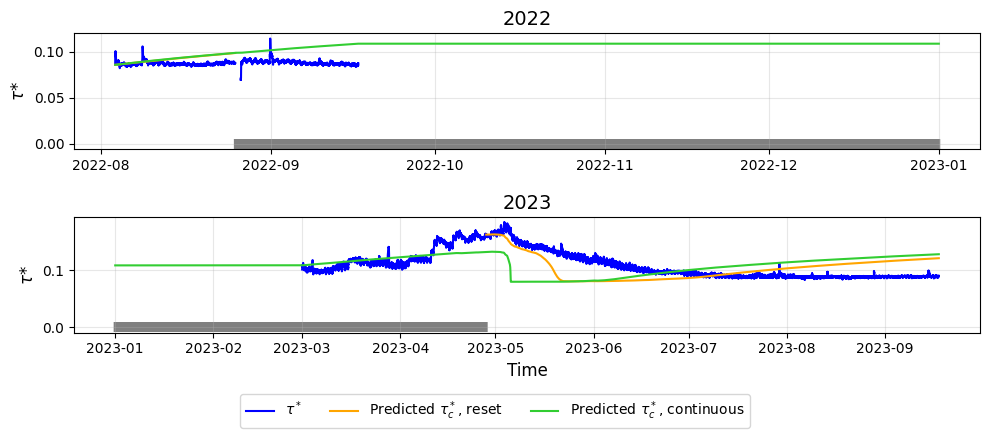

In [32]:
# tau_c_pred is the array returned by your function
tau_c_test_series = pd.Series(test, index=time_to_index.index)
tau_c_cont_series = pd.Series(test_cont, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

# select years
years = [2022, 2023]

fig, axes = plt.subplots(nrows=len(years), ncols=1, figsize=(10, 4), sharex=False)

for ax, year in zip(axes, years):
    # select data for the year
    mask = time_to_index.index.year == year
    tau_year = tau_star_series[mask]
    tauc_year = tau_c_test_series[mask]
    tauc_cont_year = tau_c_cont_series[mask]
    
    ax.plot(tau_year.index, tau_year.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
    ax.plot(tauc_year.index, tauc_year.values, color='orange', label=r'Predicted $\tau_c^*$, reset', linewidth=1.5)
    ax.plot(tauc_cont_year.index, tauc_cont_year.values, color='limegreen', label=r'Predicted $\tau_c^*$, continuous', linewidth=1.5)
    
    # optional: highlight NaNs in tau_c_pred (data gaps)
    gap_mask = np.isnan(tauc_year.values)
    ax.scatter(tauc_year.index[gap_mask], np.zeros(sum(gap_mask)), color='gray', marker='|', s=50)
    
    ax.set_ylabel(r'$\tau$*', fontsize=12)
    ax.set_title(f'{year}', fontsize=14)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time', fontsize=12)

# Create single legend from first axis
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=3, fontsize=10)

plt.tight_layout(h_pad=1.5, w_pad=0.5)
plt.show()

In [33]:
# extract modeled τ*c at events
tau_c_model_test = test[event_indices]
tau_c_model_cont = test_cont[event_indices]

# Compute MAE
mae_model_test = np.nanmean(np.abs(tau_c_model_test - tau_c_obs))
mae_model_cont = np.nanmean(np.abs(tau_c_model_cont - tau_c_obs))

print(f"MAE (dynamic τ*c model, reset): {mae_model_test:.4f}")
print(f"MAE (dynamic τ*c model, continuous): {mae_model_cont:.4f}")   
print(f"Improvement of resetting τ*c over continuous assumption (%): {(1 - mae_model_test / mae_model_cont) * 100:.1f}")

MAE (dynamic τ*c model, reset): 0.0118
MAE (dynamic τ*c model, continuous): 0.0199
Improvement of resetting τ*c over continuous assumption (%): 40.6


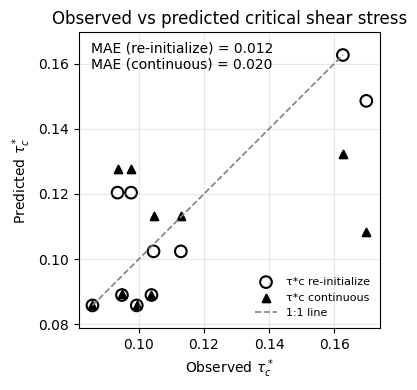

In [34]:
# axis limits for 1:1 line
vmin = min(tau_c_model_test.min(), tau_c_model_cont.min())
vmax = max(tau_c_model_test.max(), tau_c_model_cont.max())

plt.figure(figsize=(4, 4))

# with tau re-initialize at gaps
plt.scatter(tau_c_obs, tau_c_model_test, facecolors="none", edgecolors="black", s=70, linewidth=1.5, label="τ*c re-initialize")
# with tau held constant at gaps
plt.scatter(tau_c_obs, tau_c_model_cont, facecolors="black", s=30, linewidth=1.5, label="τ*c continuous", marker="^")
# 1:1 line
plt.plot([vmin, vmax], [vmin, vmax], linestyle="--", color="gray", linewidth=1.2, label="1:1 line")

plt.text(0.04, 0.97, f"MAE (re-initialize) = {mae_model_test:.3f}\nMAE (continuous) = {mae_model_cont:.3f}", transform=plt.gca().transAxes, verticalalignment="top")
plt.xlabel("Observed $\\tau^*_c$")
plt.ylabel("Predicted $\\tau^*_c$")
plt.title("Observed vs predicted critical shear stress")
plt.legend(frameon=False, fontsize=8)
plt.grid(alpha=0.3)
plt.axis("equal")

plt.tight_layout()
plt.show()

## 3) Calibrating assuming τ*c minimum during data gaps

In [35]:
# start, stop, number of values
k1_vals = np.logspace(-6, -2, 40) # values evenly spaced on log scale
k2_vals = np.logspace(-6, -2, 40)
eps_vals = np.linspace(1, 10, 10) # values from 0 to 10

results = calibrate_parameters(
    tau_star,
    event_indices,
    tau_c_obs,
    dt=15,               
    k1_vals=k1_vals,
    k2_vals=k2_vals,
    eps_vals=eps_vals,
    gamma=2.5,
    tau_c_min=0.08,
    tau_c_max=0.2,
    constant_tc=False,
    minimum_reset=True
)

best = min(results, key=lambda x: x["MAE"])

print("Best-fit parameters:")
print(best)

Testing k1 = 1.000000e-06 (1/40)


KeyboardInterrupt: 

In [36]:
test_min = evolve_tau_c_gap_minimum(
    tau_star,           # array of Shields stress τ*(t); np.nan where τ* is missing
    event_indices,      # integer indices where τ*c observations are available
    tau_c_obs,          # observed τ*c values at event_indices
    dt=15,                 # timestep between τ* samples (15 minutes in my case)
    k1=1e-06, k2=0.0007443803013251688, epsilon=7,    # these are from the third parameter iteration above
    gamma=2.5,          # fixed exponent from literature 
    tau_c_min=0.08,   # minimum τ*c
    tau_c_max=0.2,    # maximum τ*c
    )

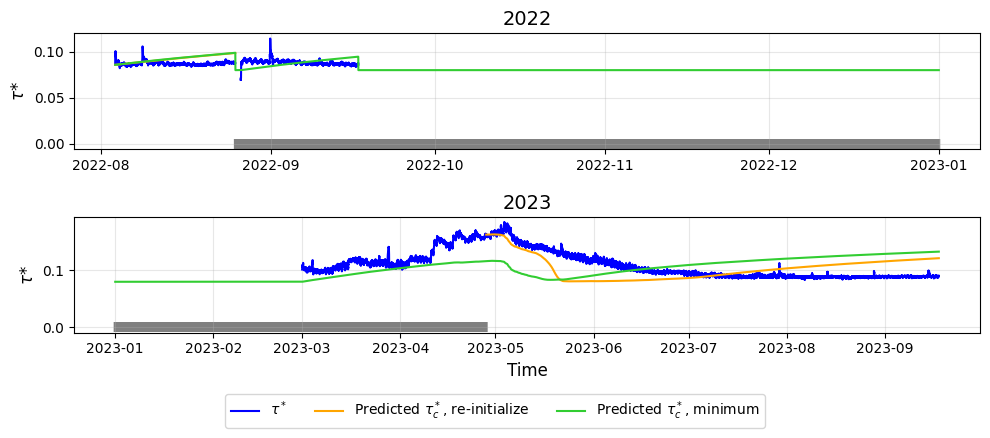

In [37]:
# tau_c_pred is the array returned by your function
tau_c_test_series = pd.Series(test, index=time_to_index.index)
tau_c_min_series = pd.Series(test_min, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

# select years
years = [2022, 2023]

fig, axes = plt.subplots(nrows=len(years), ncols=1, figsize=(10, 4), sharex=False)

for ax, year in zip(axes, years):
    # select data for the year
    mask = time_to_index.index.year == year
    tau_year = tau_star_series[mask]
    tauc_year = tau_c_test_series[mask]
    tauc_min_year = tau_c_min_series[mask]
    
    ax.plot(tau_year.index, tau_year.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
    ax.plot(tauc_year.index, tauc_year.values, color='orange', label=r'Predicted $\tau_c^*$, re-initialize', linewidth=1.5)
    ax.plot(tauc_min_year.index, tauc_min_year.values, color='limegreen', label=r'Predicted $\tau_c^*$, minimum', linewidth=1.5)
    
    # optional: highlight NaNs in tau_c_pred (data gaps)
    gap_mask = np.isnan(tauc_year.values)
    ax.scatter(tauc_year.index[gap_mask], np.zeros(sum(gap_mask)), color='gray', marker='|', s=50)
    
    ax.set_ylabel(r'$\tau$*', fontsize=12)
    ax.set_title(f'{year}', fontsize=14)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time', fontsize=12)

# Create single legend from first axis
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=3, fontsize=10)

plt.tight_layout(h_pad=1.5, w_pad=0.5)
plt.show()

In [38]:
# extract modeled τ*c at events
tau_c_model_test = test[event_indices]
tau_c_model_min = test_min[event_indices]

# Compute MAE
mae_model_test = np.nanmean(np.abs(tau_c_model_test - tau_c_obs))
mae_model_min = np.nanmean(np.abs(tau_c_model_min - tau_c_obs))
print(f"MAE (dynamic τ*c model, re-initialize): {mae_model_test:.4f}")                  
print(f"MAE (dynamic τ*c    model, minimum reset): {mae_model_min:.4f}")   
print(f"Improvement of resetting τ*c over continuous assumption (%): {(1 - mae_model_test / mae_model_min) * 100:.1f}")

MAE (dynamic τ*c model, re-initialize): 0.0118
MAE (dynamic τ*c    model, minimum reset): 0.0241
Improvement of resetting τ*c over continuous assumption (%): 51.0


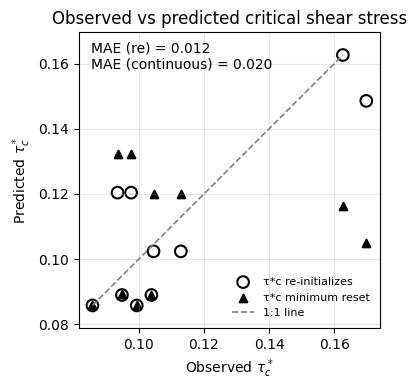

In [39]:
# axis limits for 1:1 line
vmin = min(tau_c_model_test.min(), tau_c_model_min.min())
vmax = max(tau_c_model_test.max(), tau_c_model_min.max())

plt.figure(figsize=(4, 4))

# with tau reset at gaps
plt.scatter(tau_c_obs, tau_c_model_test, facecolors="none", edgecolors="black", s=70, linewidth=1.5, label="τ*c re-initializes")
# with tau held constant at gaps
plt.scatter(tau_c_obs, tau_c_model_min, facecolors="black", s=30, linewidth=1.5, label="τ*c minimum reset", marker="^")
# 1:1 line
plt.plot([vmin, vmax], [vmin, vmax], linestyle="--", color="gray", linewidth=1.2, label="1:1 line")

plt.text(0.04, 0.97, f"MAE (re) = {mae_model_test:.3f}\nMAE (continuous) = {mae_model_cont:.3f}", transform=plt.gca().transAxes, verticalalignment="top")
plt.xlabel("Observed $\\tau^*_c$")
plt.ylabel("Predicted $\\tau^*_c$")
plt.title("Observed vs predicted critical shear stress")
plt.legend(frameon=False, fontsize=8)
plt.grid(alpha=0.3)
plt.axis("equal")

plt.tight_layout()
plt.show()

## 4) Not considering falling limb samples

In [11]:
tauc_events_rising = pd.read_csv('tauc_events_exceedance_rising_only.csv', parse_dates=['datetime'], index_col='datetime')

# remove NaT and align to available time index
tauc_events_rising = tauc_events_rising.loc[~tauc_events_rising.index.isna()]
tauc_events_rising = tauc_events_rising.loc[tauc_events_rising.index.isin(time_to_index.index)]

tauc_obs_rising = tauc_events_rising["tauc"].to_numpy()
event_indices_rising = time_to_index.loc[tauc_events_rising.index].to_numpy()
print(f"Number of rising events: {len(event_indices_rising)}")
print(f"Observed τ*c values for rising events: {tauc_obs_rising}")

Number of rising events: 5
Observed τ*c values for rising events: [0.08577 0.10389 0.16268 0.11292 0.09764]


### 4.a) Assuming τ*c re-initializes

In [27]:
# determining range of calibration parameters to test
k1_vals = np.logspace(-6, -2, 40) # values evenly spaced on log scale
k2_vals = np.logspace(-6, -2, 40)
eps_vals = np.linspace(1, 10, 10) # values from 0 to 10

results = calibrate_parameters(
    tau_star,
    event_indices_rising,
    tauc_obs_rising,
    dt=15,               
    k1_vals=k1_vals,
    k2_vals=k2_vals,
    eps_vals=eps_vals,
    gamma=2.5,
    tau_c_min=0.08,
    tau_c_max=0.2
)

best = min(results, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing k1 = 1.000000e-06 (1/40)
Testing k1 = 1.266380e-06 (2/40)
Testing k1 = 1.603719e-06 (3/40)
Testing k1 = 2.030918e-06 (4/40)
Testing k1 = 2.571914e-06 (5/40)
Testing k1 = 3.257021e-06 (6/40)
Testing k1 = 4.124626e-06 (7/40)
Testing k1 = 5.223345e-06 (8/40)
Testing k1 = 6.614741e-06 (9/40)
Testing k1 = 8.376776e-06 (10/40)
Testing k1 = 1.060818e-05 (11/40)
Testing k1 = 1.343399e-05 (12/40)
Testing k1 = 1.701254e-05 (13/40)
Testing k1 = 2.154435e-05 (14/40)
Testing k1 = 2.728333e-05 (15/40)
Testing k1 = 3.455107e-05 (16/40)
Testing k1 = 4.375479e-05 (17/40)
Testing k1 = 5.541020e-05 (18/40)
Testing k1 = 7.017038e-05 (19/40)
Testing k1 = 8.886238e-05 (20/40)
Testing k1 = 1.125336e-04 (21/40)
Testing k1 = 1.425103e-04 (22/40)
Testing k1 = 1.804722e-04 (23/40)
Testing k1 = 2.285464e-04 (24/40)
Testing k1 = 2.894266e-04 (25/40)
Testing k1 = 3.665241e-04 (26/40)
Testing k1 = 4.641589e-04 (27/40)
Testing k1 = 5.878016e-04 (28/40)
Testing k1 = 7.443803e-04 (29/40)
Testing k1 = 9.426685e-

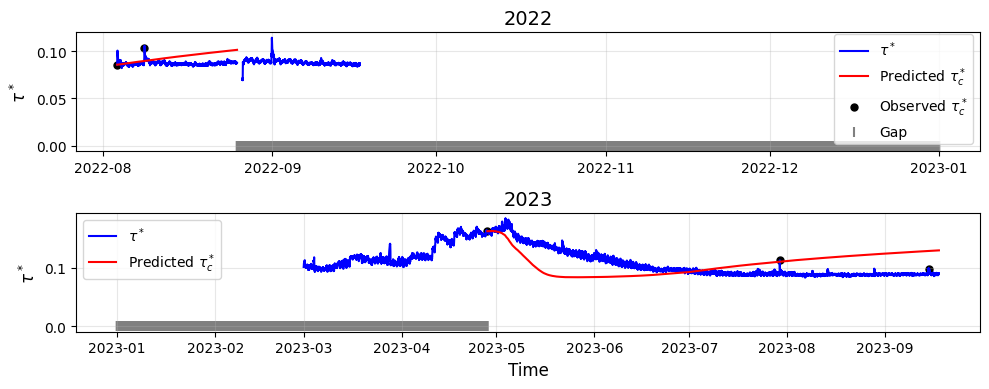

In [66]:
calibration = evolve_tau_c_gap_reset(
    tau_star, event_indices_rising, tauc_obs_rising, dt=15,                 
    k1=1.2663801734674021e-06, k2=5.541020330009492e-05, epsilon=1,    # best fit model parameters from above
    gamma=2.5, tau_c_min=0.08, tau_c_max=0.2)

# export calibration parameters and MAE to csv
#results_df = pd.DataFrame(results)
#results_df.to_csv('calibration/no_falling_limb/nofalling_reinitialized_calibration.csv', index=False)

# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(calibration, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)
# select years
years = [2022, 2023]

# plotting calibration results
fig, axes = plt.subplots(nrows=len(years), ncols=1, figsize=(10, 4), sharex=False)

for ax, year in zip(axes, years):
    # select data for the year
    mask = time_to_index.index.year == year
    tau_year = tau_star_series[mask]
    tauc_year = tau_c_pred_series[mask]

    # observed τ*c (rising-only) for this year
    obs_tauc_year = tauc_events_rising.loc[tauc_events_rising.index.year == year, "tauc"]

    ax.plot(tau_year.index, tau_year.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
    ax.plot(tauc_year.index, tauc_year.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)

    # observed τ*c as black dots
    ax.scatter(obs_tauc_year.index, obs_tauc_year.values, color='black', s=25, label=r'Observed $\tau_c^*$' if year==2022 else "")

    # optional: highlight NaNs in tau_c_pred (data gaps)
    gap_mask = np.isnan(tauc_year.values)
    ax.scatter(tauc_year.index[gap_mask], np.zeros(sum(gap_mask)), color='gray', marker='|', s=50, label='Gap' if year==2022 else "")

    ax.set_ylabel(r'$\tau^*$', fontsize=12)
    ax.set_title(f'{year}', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time', fontsize=12)

plt.tight_layout()
plt.show()

MAE (dynamic τ*c model): 0.0095
MAE (constant mean τ*c): 0.0202
Model improvement over constant τ*c (%): 52.7


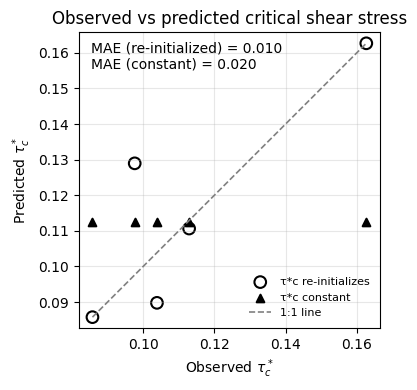

In [56]:
# constant (mean) τ*c baseline
tau_c_mean = np.nanmean(tauc_obs_rising)
# "predicted" τ*c assuming constant mean
tau_c_const_pred = np.full_like(tauc_obs_rising, tau_c_mean)
# extract modeled τ*c at events
tau_c_model_pred = calibration[event_indices_rising]

# Compute MAE
mae_model = np.nanmean(np.abs(tau_c_model_pred - tauc_obs_rising))
mae_const = np.nanmean(np.abs(tau_c_const_pred - tauc_obs_rising))

print(f"MAE (dynamic τ*c model): {mae_model:.4f}")
print(f"MAE (constant mean τ*c): {mae_const:.4f}")
print(f"Model improvement over constant τ*c (%): {(1 - mae_model / mae_const) * 100:.1f}")

# axis limits for 1:1 line
vmin = min(tau_c_model_pred.min(), tau_c_const_pred.min())
vmax = max(tau_c_model_pred.max(), tau_c_const_pred.max())

plt.figure(figsize=(4, 4))

# with tau reset at gaps
plt.scatter(tauc_obs_rising, tau_c_model_pred, facecolors="none", edgecolors="black", s=70, linewidth=1.5, label="τ*c re-initializes")
# with tau held constant at gaps
plt.scatter(tauc_obs_rising, tau_c_const_pred, facecolors="black", s=30, linewidth=1.5, label="τ*c constant", marker="^")
# 1:1 line
plt.plot([vmin, vmax], [vmin, vmax], linestyle="--", color="gray", linewidth=1.2, label="1:1 line")

plt.text(0.04, 0.97, f"MAE (re-initialized) = {mae_model:.3f}\nMAE (constant) = {mae_const:.3f}", transform=plt.gca().transAxes, verticalalignment="top")
plt.xlabel("Observed $\\tau^*_c$")
plt.ylabel("Predicted $\\tau^*_c$")
plt.title("Observed vs predicted critical shear stress")
plt.legend(frameon=False, fontsize=8)
plt.grid(alpha=0.3)
plt.axis("equal")

plt.tight_layout()
plt.show()


### 4.b) Assuming continuous τ*c

In [57]:
# determining range of calibration parameters to test
k1_vals = np.logspace(-6, -2, 40) # values evenly spaced on log scale
k2_vals = np.logspace(-6, -2, 40)
eps_vals = np.linspace(1, 10, 10) # values from 0 to 10

results = calibrate_parameters(
    tau_star,
    event_indices_rising,
    tauc_obs_rising,
    dt=15,               
    k1_vals=k1_vals,
    k2_vals=k2_vals,
    eps_vals=eps_vals,
    gamma=2.5,
    tau_c_min=0.08,
    tau_c_max=0.2,
    constant_tc=True,
)

best = min(results, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing k1 = 1.000000e-06 (1/40)
Testing k1 = 1.266380e-06 (2/40)
Testing k1 = 1.603719e-06 (3/40)
Testing k1 = 2.030918e-06 (4/40)
Testing k1 = 2.571914e-06 (5/40)
Testing k1 = 3.257021e-06 (6/40)
Testing k1 = 4.124626e-06 (7/40)
Testing k1 = 5.223345e-06 (8/40)
Testing k1 = 6.614741e-06 (9/40)
Testing k1 = 8.376776e-06 (10/40)
Testing k1 = 1.060818e-05 (11/40)
Testing k1 = 1.343399e-05 (12/40)
Testing k1 = 1.701254e-05 (13/40)
Testing k1 = 2.154435e-05 (14/40)
Testing k1 = 2.728333e-05 (15/40)
Testing k1 = 3.455107e-05 (16/40)
Testing k1 = 4.375479e-05 (17/40)
Testing k1 = 5.541020e-05 (18/40)
Testing k1 = 7.017038e-05 (19/40)
Testing k1 = 8.886238e-05 (20/40)
Testing k1 = 1.125336e-04 (21/40)
Testing k1 = 1.425103e-04 (22/40)
Testing k1 = 1.804722e-04 (23/40)
Testing k1 = 2.285464e-04 (24/40)
Testing k1 = 2.894266e-04 (25/40)
Testing k1 = 3.665241e-04 (26/40)
Testing k1 = 4.641589e-04 (27/40)
Testing k1 = 5.878016e-04 (28/40)
Testing k1 = 7.443803e-04 (29/40)
Testing k1 = 9.426685e-

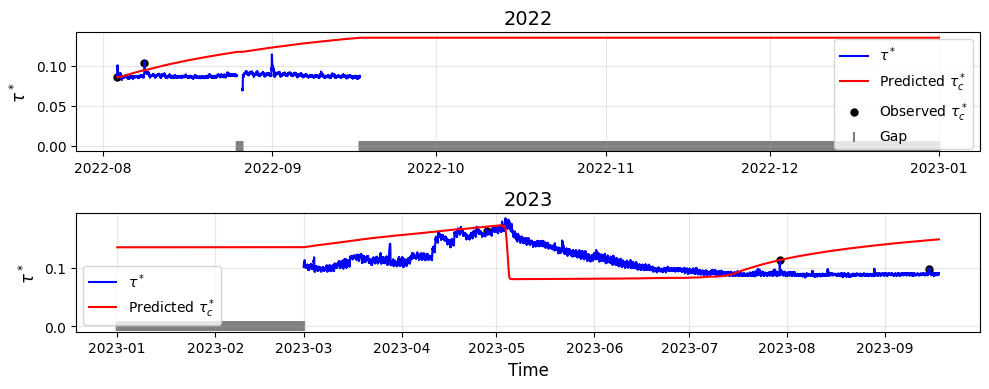

In [67]:
calibration = evolve_tau_c_gap_hold(
    tau_star, event_indices, tau_c_obs, dt=15,                 
    k1=3.257020655659783e-06, k2=0.00046415888336127773, epsilon=1,    # best fit model parameters from above
    gamma=2.5, tau_c_min=0.08, tau_c_max=0.2)

# export calibration parameters and MAE to csv
results_df = pd.DataFrame(results)
results_df.to_csv('calibration/no_falling_limb/nofalling_continuous_calibration.csv', index=False)

# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(calibration, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)
# select years
years = [2022, 2023]

# plotting calibration results
fig, axes = plt.subplots(nrows=len(years), ncols=1, figsize=(10, 4), sharex=False)

for ax, year in zip(axes, years):
    # select data for the year
    mask = time_to_index.index.year == year
    tau_year = tau_star_series[mask]
    tauc_year = tau_c_pred_series[mask]

    # observed τ*c (rising-only) for this year
    obs_tauc_year = tauc_events_rising.loc[tauc_events_rising.index.year == year, "tauc"]

    ax.plot(tau_year.index, tau_year.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
    ax.plot(tauc_year.index, tauc_year.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
    # observed τ*c as black dots
    ax.scatter(obs_tauc_year.index, obs_tauc_year.values, color='black', s=25, label=r'Observed $\tau_c^*$' if year==2022 else "")

    # highlight NaNs in tau_c_pred (data gaps)
    gap_mask = np.isnan(tau_year.values)
    ax.scatter(tau_year.index[gap_mask], np.zeros(sum(gap_mask)), color='gray', marker='|', s=50, label='Gap' if year==2022 else "")

    ax.set_ylabel(r'$\tau^*$', fontsize=12)
    ax.set_title(f'{year}', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time', fontsize=12)

plt.tight_layout()
plt.show()

MAE (dynamic τ*c model): 0.0135
MAE (constant mean τ*c): 0.0202
Model improvement over constant τ*c (%): 33.3


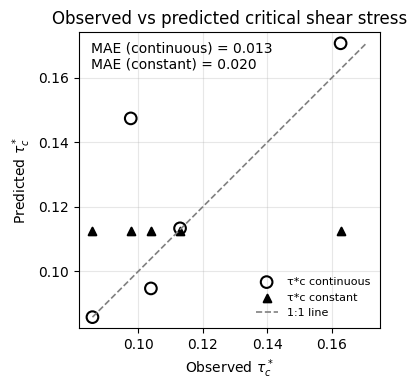

In [68]:
# constant (mean) τ*c baseline
tau_c_mean = np.nanmean(tauc_obs_rising)
# "predicted" τ*c assuming constant mean
tau_c_const_pred = np.full_like(tauc_obs_rising, tau_c_mean)
# extract modeled τ*c at events
tau_c_model_pred = calibration[event_indices_rising]

# Compute MAE
mae_model = np.nanmean(np.abs(tau_c_model_pred - tauc_obs_rising))
mae_const = np.nanmean(np.abs(tau_c_const_pred - tauc_obs_rising))

print(f"MAE (dynamic τ*c model): {mae_model:.4f}")
print(f"MAE (constant mean τ*c): {mae_const:.4f}")
print(f"Model improvement over constant τ*c (%): {(1 - mae_model / mae_const) * 100:.1f}")

# axis limits for 1:1 line
vmin = min(tau_c_model_pred.min(), tau_c_const_pred.min())
vmax = max(tau_c_model_pred.max(), tau_c_const_pred.max())

plt.figure(figsize=(4, 4))

# with tau reset at gaps
plt.scatter(tauc_obs_rising, tau_c_model_pred, facecolors="none", edgecolors="black", s=70, linewidth=1.5, label="τ*c continuous")
# with tau held constant at gaps
plt.scatter(tauc_obs_rising, tau_c_const_pred, facecolors="black", s=30, linewidth=1.5, label="τ*c constant", marker="^")
# 1:1 line
plt.plot([vmin, vmax], [vmin, vmax], linestyle="--", color="gray", linewidth=1.2, label="1:1 line")

plt.text(0.04, 0.97, f"MAE (continuous) = {mae_model:.3f}\nMAE (constant) = {mae_const:.3f}", transform=plt.gca().transAxes, verticalalignment="top")
plt.xlabel("Observed $\\tau^*_c$")
plt.ylabel("Predicted $\\tau^*_c$")
plt.title("Observed vs predicted critical shear stress")
plt.legend(frameon=False, fontsize=8)
plt.grid(alpha=0.3)
plt.axis("equal")

plt.tight_layout()
plt.show()


### 4.c) Assuming τ*c minimum

In [69]:
# determining range of calibration parameters to test
k1_vals = np.logspace(-6, -2, 40) # values evenly spaced on log scale
k2_vals = np.logspace(-6, -2, 40)
eps_vals = np.linspace(1, 10, 10) # values from 0 to 10

results = calibrate_parameters(
    tau_star,
    event_indices_rising,
    tauc_obs_rising,
    dt=15,               
    k1_vals=k1_vals,
    k2_vals=k2_vals,
    eps_vals=eps_vals,
    gamma=2.5,
    tau_c_min=0.08,
    tau_c_max=0.2,
    constant_tc=False,
    minimum_reset=True
)

best = min(results, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing k1 = 1.000000e-06 (1/40)
Testing k1 = 1.266380e-06 (2/40)
Testing k1 = 1.603719e-06 (3/40)
Testing k1 = 2.030918e-06 (4/40)
Testing k1 = 2.571914e-06 (5/40)
Testing k1 = 3.257021e-06 (6/40)
Testing k1 = 4.124626e-06 (7/40)
Testing k1 = 5.223345e-06 (8/40)
Testing k1 = 6.614741e-06 (9/40)
Testing k1 = 8.376776e-06 (10/40)
Testing k1 = 1.060818e-05 (11/40)
Testing k1 = 1.343399e-05 (12/40)
Testing k1 = 1.701254e-05 (13/40)
Testing k1 = 2.154435e-05 (14/40)
Testing k1 = 2.728333e-05 (15/40)
Testing k1 = 3.455107e-05 (16/40)
Testing k1 = 4.375479e-05 (17/40)
Testing k1 = 5.541020e-05 (18/40)
Testing k1 = 7.017038e-05 (19/40)
Testing k1 = 8.886238e-05 (20/40)
Testing k1 = 1.125336e-04 (21/40)
Testing k1 = 1.425103e-04 (22/40)
Testing k1 = 1.804722e-04 (23/40)
Testing k1 = 2.285464e-04 (24/40)
Testing k1 = 2.894266e-04 (25/40)
Testing k1 = 3.665241e-04 (26/40)
Testing k1 = 4.641589e-04 (27/40)
Testing k1 = 5.878016e-04 (28/40)
Testing k1 = 7.443803e-04 (29/40)
Testing k1 = 9.426685e-

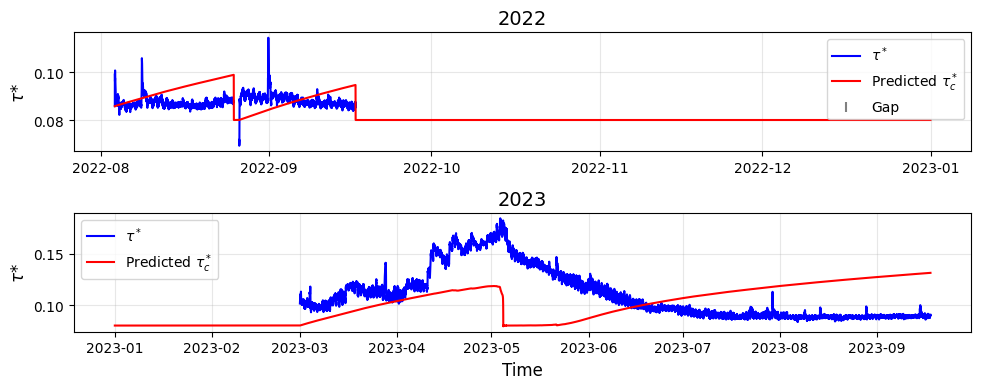

In [12]:
calibration = evolve_tau_c_gap_minimum(
    tau_star, event_indices, tau_c_obs, dt=15,                 
    k1=1e-06, k2=0.01, epsilon=10,    # best fit model parameters from above
    gamma=2.5, tau_c_min=0.08, tau_c_max=0.2)

# export calibration parameters and MAE to csv
#results_df = pd.DataFrame(results)
#results_df.to_csv('calibration/no_falling_limb/nofalling_minimum_calibration.csv',
#    index=False)

# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(calibration, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)
# select years
years = [2022, 2023]

# plotting calibration results
fig, axes = plt.subplots(nrows=len(years), ncols=1, figsize=(10, 4), sharex=False)

for ax, year in zip(axes, years):
    # select data for the year
    mask = time_to_index.index.year == year
    tau_year = tau_star_series[mask]
    tauc_year = tau_c_pred_series[mask]
    
    ax.plot(tau_year.index, tau_year.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
    ax.plot(tauc_year.index, tauc_year.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
    
    # optional: highlight NaNs in tau_c_pred (data gaps)
    gap_mask = np.isnan(tauc_year.values)
    ax.scatter(tauc_year.index[gap_mask], np.zeros(sum(gap_mask)), color='gray', marker='|', s=50, label='Gap' if year==2022 else "")
    
    ax.set_ylabel(r'$\tau$*', fontsize=12)
    ax.set_title(f'{year}', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time', fontsize=12)

plt.tight_layout()
plt.show()

MAE (dynamic τ*c model): 0.0196
MAE (constant mean τ*c): 0.0202
Model improvement over constant τ*c (%): 2.9


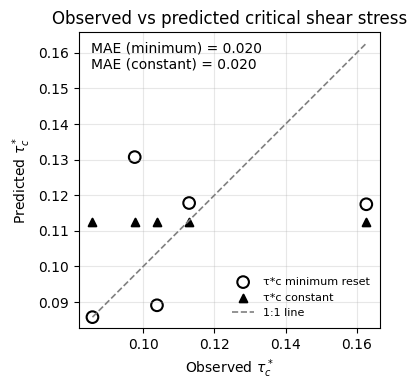

In [18]:
# constant (mean) τ*c baseline
tau_c_mean = np.nanmean(tauc_obs_rising)
# "predicted" τ*c assuming constant mean
tau_c_const_pred = np.full_like(tauc_obs_rising, tau_c_mean)
# extract modeled τ*c at events
tau_c_model_pred = calibration[event_indices_rising]

# Compute MAE
mae_model = np.nanmean(np.abs(tau_c_model_pred - tauc_obs_rising))
mae_const = np.nanmean(np.abs(tau_c_const_pred - tauc_obs_rising))

print(f"MAE (dynamic τ*c model): {mae_model:.4f}")
print(f"MAE (constant mean τ*c): {mae_const:.4f}")
print(f"Model improvement over constant τ*c (%): {(1 - mae_model / mae_const) * 100:.1f}")

# axis limits for 1:1 line
vmin = min(tau_c_model_pred.min(), tau_c_const_pred.min(), tauc_obs_rising.min())
vmax = max(tau_c_model_pred.max(), tau_c_const_pred.max(), tauc_obs_rising.max())

plt.figure(figsize=(4, 4))

# with tau reset at gaps
plt.scatter(tauc_obs_rising, tau_c_model_pred, facecolors="none", edgecolors="black", s=70, linewidth=1.5, label="τ*c minimum reset")
# with tau held constant at gaps
plt.scatter(tauc_obs_rising, tau_c_const_pred, facecolors="black", s=30, linewidth=1.5, label="τ*c constant", marker="^")
# 1:1 line
plt.plot([vmin, vmax], [vmin, vmax], linestyle="--", color="gray", linewidth=1.2, label="1:1 line")

plt.text(0.04, 0.97, f"MAE (minimum) = {mae_model:.3f}\nMAE (constant) = {mae_const:.3f}", transform=plt.gca().transAxes, verticalalignment="top")
plt.xlabel("Observed $\\tau^*_c$")
plt.ylabel("Predicted $\\tau^*_c$")
plt.title("Observed vs predicted critical shear stress")
plt.legend(frameon=False, fontsize=8)
plt.grid(alpha=0.3)
plt.axis("equal")

plt.tight_layout()
plt.show()


## 5) Independent year calibration

In [25]:
# separate tau record by year 
tau_star_series = pd.Series(tau_star, index=time_to_index.index)
tau_2022 = tau_star_series[tau_star_series.index.year == 2022]
tau_2023 = tau_star_series[tau_star_series.index.year == 2023]

### 5.a) 2022

In [28]:
# filter events to 2022 only
tauc_events_2022 = tauc_events[tauc_events.index.year == 2022]
# create time-to-index mapping for 2022 subset
time_to_index_2022 = pd.Series(np.arange(len(tau_2022)), index=tau_2022.index)
# calculate event indices relative to 2022 array
event_indices_2022 = time_to_index_2022.loc[tauc_events_2022.index].to_numpy()
tauc_obs_2022 = tauc_events_2022["tauc"].to_numpy()

# determining range of calibration parameters to test
k1_vals = np.logspace(-6, -2, 40) # values evenly spaced on log scale
k2_vals = np.logspace(-6, -2, 40)
eps_vals = np.linspace(1, 10, 10) # values from 0 to 10

results = calibrate_parameters(
    tau_2022.to_numpy(),
    event_indices_2022,
    tauc_obs_2022,
    dt=15,               
    k1_vals=k1_vals,
    k2_vals=k2_vals,
    eps_vals=eps_vals,
    gamma=2.5,
    tau_c_min=0.08,
    tau_c_max=0.2,
)

best = min(results, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing k1 = 1.000000e-06 (1/40)
Testing k1 = 1.266380e-06 (2/40)
Testing k1 = 1.603719e-06 (3/40)
Testing k1 = 2.030918e-06 (4/40)
Testing k1 = 2.571914e-06 (5/40)
Testing k1 = 3.257021e-06 (6/40)
Testing k1 = 4.124626e-06 (7/40)
Testing k1 = 5.223345e-06 (8/40)
Testing k1 = 6.614741e-06 (9/40)
Testing k1 = 8.376776e-06 (10/40)
Testing k1 = 1.060818e-05 (11/40)
Testing k1 = 1.343399e-05 (12/40)
Testing k1 = 1.701254e-05 (13/40)
Testing k1 = 2.154435e-05 (14/40)
Testing k1 = 2.728333e-05 (15/40)
Testing k1 = 3.455107e-05 (16/40)
Testing k1 = 4.375479e-05 (17/40)
Testing k1 = 5.541020e-05 (18/40)
Testing k1 = 7.017038e-05 (19/40)
Testing k1 = 8.886238e-05 (20/40)
Testing k1 = 1.125336e-04 (21/40)
Testing k1 = 1.425103e-04 (22/40)
Testing k1 = 1.804722e-04 (23/40)
Testing k1 = 2.285464e-04 (24/40)
Testing k1 = 2.894266e-04 (25/40)
Testing k1 = 3.665241e-04 (26/40)
Testing k1 = 4.641589e-04 (27/40)
Testing k1 = 5.878016e-04 (28/40)
Testing k1 = 7.443803e-04 (29/40)
Testing k1 = 9.426685e-

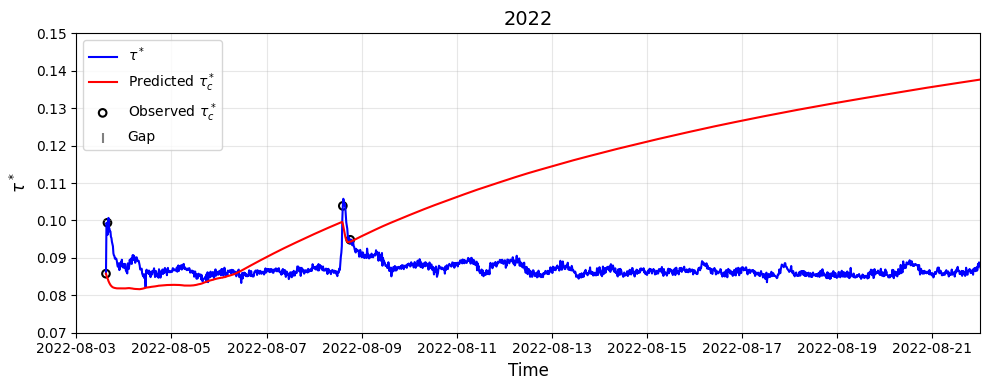

In [35]:
calibration = evolve_tau_c_gap_reset(
    tau_2022.to_numpy(),  # Use 2022 data only
    event_indices_2022,
    tauc_obs_2022,   # best fit model parameters from above
    dt=15,                 
    k1=1.0608183551394482e-05, k2=0.0049238826317067365, epsilon=1,
    gamma=2.5, tau_c_min=0.08, tau_c_max=0.2)

# export calibration parameters and MAE to csv
results_df = pd.DataFrame(results)
results_df.to_csv('calibration/independent_year/2022_calibration.csv', index=False)

# Create calibration result series using 2022 time index
tau_c_pred_series_2022 = pd.Series(calibration, index=time_to_index_2022.index)

# select years
years = [2022]

# plotting calibration results
fig, ax = plt.subplots(figsize=(10, 4))

# use 2022 data directly
ax.plot(tau_2022.index, tau_2022.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series_2022.index, tau_c_pred_series_2022.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)

# plot observed τ*c values for 2022
ax.scatter(tauc_events_2022.index, tauc_events_2022["tauc"], 
           facecolors="none", edgecolors="black", s=30, linewidth=1.5, 
           label=r'Observed $\tau_c^*$')

# highlight NaNs in tau_c_pred (data gaps)
gap_mask = np.isnan(tau_c_pred_series_2022.values)
ax.scatter(tau_c_pred_series_2022.index[gap_mask], np.zeros(sum(gap_mask)), 
           color='gray', marker='|', s=50, label='Gap')

ax.set_xlim(pd.Timestamp('2022-08-03'), pd.Timestamp('2022-08-22'))
ax.set_ylim(0.07, 0.15)
ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.set_title('2022', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

MAE (dynamic τ*c model): 0.0050
MAE (constant mean τ*c): 0.0057
Model improvement over constant τ*c (%): 11.4


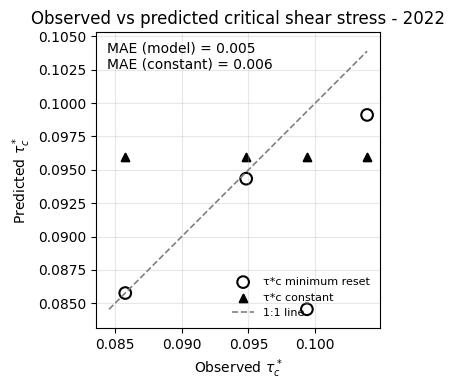

In [39]:
# constant (mean) τ*c baseline
tau_c_mean = np.nanmean(tauc_obs_2022)
# "predicted" τ*c assuming constant mean
tau_c_const_pred = np.full_like(tauc_obs_2022, tau_c_mean)
# extract modeled τ*c at events
tau_c_model_pred = calibration[event_indices_2022]

# Compute MAE
mae_model = np.nanmean(np.abs(tau_c_model_pred - tauc_obs_2022))
mae_const = np.nanmean(np.abs(tau_c_const_pred - tauc_obs_2022))

print(f"MAE (dynamic τ*c model): {mae_model:.4f}")
print(f"MAE (constant mean τ*c): {mae_const:.4f}")
print(f"Model improvement over constant τ*c (%): {(1 - mae_model / mae_const) * 100:.1f}")

# axis limits for 1:1 line
vmin = min(tau_c_model_pred.min(), tau_c_const_pred.min(), tauc_obs_2022.min())
vmax = max(tau_c_model_pred.max(), tau_c_const_pred.max(), tauc_obs_2022.max())

plt.figure(figsize=(4, 4))

# with tau reset at gaps
plt.scatter(tauc_obs_2022, tau_c_model_pred, facecolors="none", edgecolors="black", s=70, linewidth=1.5, label="τ*c minimum reset")
# with tau held constant at gaps
plt.scatter(tauc_obs_2022, tau_c_const_pred, facecolors="black", s=30, linewidth=1.5, label="τ*c constant", marker="^")
# 1:1 line
plt.plot([vmin, vmax], [vmin, vmax], linestyle="--", color="gray", linewidth=1.2, label="1:1 line")

plt.text(0.04, 0.97, f"MAE (model) = {mae_model:.3f}\nMAE (constant) = {mae_const:.3f}", transform=plt.gca().transAxes, verticalalignment="top")
plt.xlabel("Observed $\\tau^*_c$")
plt.ylabel("Predicted $\\tau^*_c$")
plt.title("Observed vs predicted critical shear stress - 2022")
plt.legend(frameon=False, fontsize=8, loc='lower right')
plt.grid(alpha=0.3)
plt.axis("equal")

plt.tight_layout()
plt.show()

### 5.b) 2023

In [40]:
# filter events to 2022 only
tauc_events_2023 = tauc_events[tauc_events.index.year == 2023]
# create time-to-index mapping for 2023 subset
time_to_index_2023 = pd.Series(np.arange(len(tau_2023)), index=tau_2023.index)
# calculate event indices relative to 2023 array
event_indices_2023 = time_to_index_2023.loc[tauc_events_2023.index].to_numpy()
tauc_obs_2023 = tauc_events_2023["tauc"].to_numpy()

# determining range of calibration parameters to test
k1_vals = np.logspace(-6, -2, 40) # values evenly spaced on log scale
k2_vals = np.logspace(-6, -2, 40)
eps_vals = np.linspace(1, 10, 10) # values from 0 to 10

results = calibrate_parameters(
    tau_2023.to_numpy(),
    event_indices_2023,
    tauc_obs_2023,
    dt=15,               
    k1_vals=k1_vals,
    k2_vals=k2_vals,
    eps_vals=eps_vals,
    gamma=2.5,
    tau_c_min=0.08,
    tau_c_max=0.2,
)

best = min(results, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing k1 = 1.000000e-06 (1/40)
Testing k1 = 1.266380e-06 (2/40)
Testing k1 = 1.603719e-06 (3/40)
Testing k1 = 2.030918e-06 (4/40)
Testing k1 = 2.571914e-06 (5/40)
Testing k1 = 3.257021e-06 (6/40)
Testing k1 = 4.124626e-06 (7/40)
Testing k1 = 5.223345e-06 (8/40)
Testing k1 = 6.614741e-06 (9/40)
Testing k1 = 8.376776e-06 (10/40)
Testing k1 = 1.060818e-05 (11/40)
Testing k1 = 1.343399e-05 (12/40)
Testing k1 = 1.701254e-05 (13/40)
Testing k1 = 2.154435e-05 (14/40)
Testing k1 = 2.728333e-05 (15/40)
Testing k1 = 3.455107e-05 (16/40)
Testing k1 = 4.375479e-05 (17/40)
Testing k1 = 5.541020e-05 (18/40)
Testing k1 = 7.017038e-05 (19/40)
Testing k1 = 8.886238e-05 (20/40)
Testing k1 = 1.125336e-04 (21/40)
Testing k1 = 1.425103e-04 (22/40)
Testing k1 = 1.804722e-04 (23/40)
Testing k1 = 2.285464e-04 (24/40)
Testing k1 = 2.894266e-04 (25/40)
Testing k1 = 3.665241e-04 (26/40)
Testing k1 = 4.641589e-04 (27/40)
Testing k1 = 5.878016e-04 (28/40)
Testing k1 = 7.443803e-04 (29/40)
Testing k1 = 9.426685e-

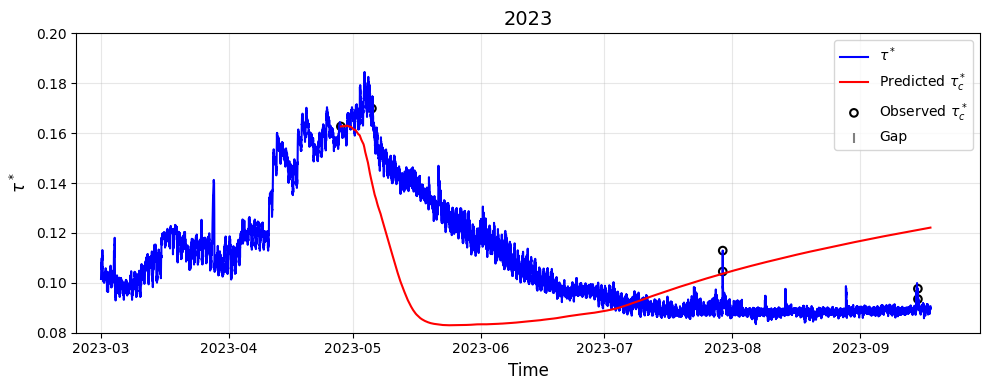

In [46]:
calibration = evolve_tau_c_gap_reset(
    tau_2023.to_numpy(),  # Use 2023 data only
    event_indices_2023,
    tauc_obs_2023,   # best fit model parameters from above
    dt=15,                 
    k1=1e-06, k2=5.541020330009492e-05, epsilon=1,
    gamma=2.5, tau_c_min=0.08, tau_c_max=0.2)

# export calibration parameters and MAE to csv
results_df = pd.DataFrame(results)
results_df.to_csv('calibration/independent_year/2023_calibration.csv', index=False)

# Create calibration result series using 2023 time index
tau_c_pred_series_2023 = pd.Series(calibration, index=time_to_index_2023.index)

# select years
years = [2023]

# plotting calibration results
fig, ax = plt.subplots(figsize=(10, 4))

# use 2023 data directly
ax.plot(tau_2023.index, tau_2023.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series_2023.index, tau_c_pred_series_2023.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)

# plot observed τ*c values for 2023
ax.scatter(tauc_events_2023.index, tauc_events_2023["tauc"], 
           facecolors="none", edgecolors="black", s=30, linewidth=1.5, 
           label=r'Observed $\tau_c^*$')

# highlight NaNs in tau_c_pred (data gaps)
gap_mask = np.isnan(tau_c_pred_series_2023.values)
ax.scatter(tau_c_pred_series_2023.index[gap_mask], np.zeros(sum(gap_mask)), 
           color='gray', marker='|', s=50, label='Gap')

ax.set_xlim(pd.Timestamp('2023-02-23'), pd.Timestamp('2023-09-30'))
ax.set_ylim(0.08, 0.2)
ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.set_title('2023', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

MAE (dynamic τ*c model): 0.0152
MAE (constant mean τ*c): 0.0285
Model improvement over constant τ*c (%): 46.7


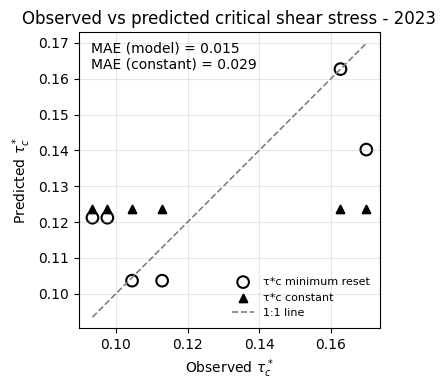

In [47]:
# constant (mean) τ*c baseline
tau_c_mean = np.nanmean(tauc_obs_2023)
# "predicted" τ*c assuming constant mean
tau_c_const_pred = np.full_like(tauc_obs_2023, tau_c_mean)
# extract modeled τ*c at events
tau_c_model_pred = calibration[event_indices_2023]

# Compute MAE
mae_model = np.nanmean(np.abs(tau_c_model_pred - tauc_obs_2023))
mae_const = np.nanmean(np.abs(tau_c_const_pred - tauc_obs_2023))

print(f"MAE (dynamic τ*c model): {mae_model:.4f}")
print(f"MAE (constant mean τ*c): {mae_const:.4f}")
print(f"Model improvement over constant τ*c (%): {(1 - mae_model / mae_const) * 100:.1f}")

# axis limits for 1:1 line
vmin = min(tau_c_model_pred.min(), tau_c_const_pred.min(), tauc_obs_2023.min())
vmax = max(tau_c_model_pred.max(), tau_c_const_pred.max(), tauc_obs_2023.max())

plt.figure(figsize=(4, 4))

# with tau reset at gaps
plt.scatter(tauc_obs_2023, tau_c_model_pred, facecolors="none", edgecolors="black", s=70, linewidth=1.5, label="τ*c minimum reset")
# with tau held constant at gaps
plt.scatter(tauc_obs_2023, tau_c_const_pred, facecolors="black", s=30, linewidth=1.5, label="τ*c constant", marker="^")
# 1:1 line
plt.plot([vmin, vmax], [vmin, vmax], linestyle="--", color="gray", linewidth=1.2, label="1:1 line")

plt.text(0.04, 0.97, f"MAE (model) = {mae_model:.3f}\nMAE (constant) = {mae_const:.3f}", transform=plt.gca().transAxes, verticalalignment="top")
plt.xlabel("Observed $\\tau^*_c$")
plt.ylabel("Predicted $\\tau^*_c$")
plt.title("Observed vs predicted critical shear stress - 2023")
plt.legend(frameon=False, fontsize=8, loc='lower right')
plt.grid(alpha=0.3)
plt.axis("equal")

plt.tight_layout()
plt.show()